# 🧠 ROI Stack Explorer
Load an ROI stack, look at it, and prepare it for ML in a few lines.
Run the cells top to bottom. All helpers come from [`roi_utils.py`](https://github.com/24f2007780/colab_export_roi).

## 1. Setup

In [20]:
# !wget -q -O roi_utils.py https://raw.githubusercontent.com/24f2007780/colab_export_roi/refs/heads/main/roi_utils.py

import sys
from pathlib import Path
if ".." not in sys.path:
    sys.path.append("..")

# Data directory: notebooks/data or stroke_notebooks/data
DATA_DIR = Path("data") if Path("data").is_dir() else Path("../data") if Path("../data").is_dir() else Path(".")

import importlib, roi_utils
importlib.reload(roi_utils)                     # in case an older copy was already imported this session
from roi_utils import *


## 2. Load your ROI stack

Filename : MRI_SE687_X414_Y698_Z123_1200x1200_L0_axial.npy
Shape    : (123, 1200, 854, 1)
Dtype    : uint8
Size     : 120.21 MB

Parsed Metadata:
  • Center X                 : 414
  • Center Y                 : 698
  • Z / section information  : Section 687, Z=123
  • Resolution               : Level 0


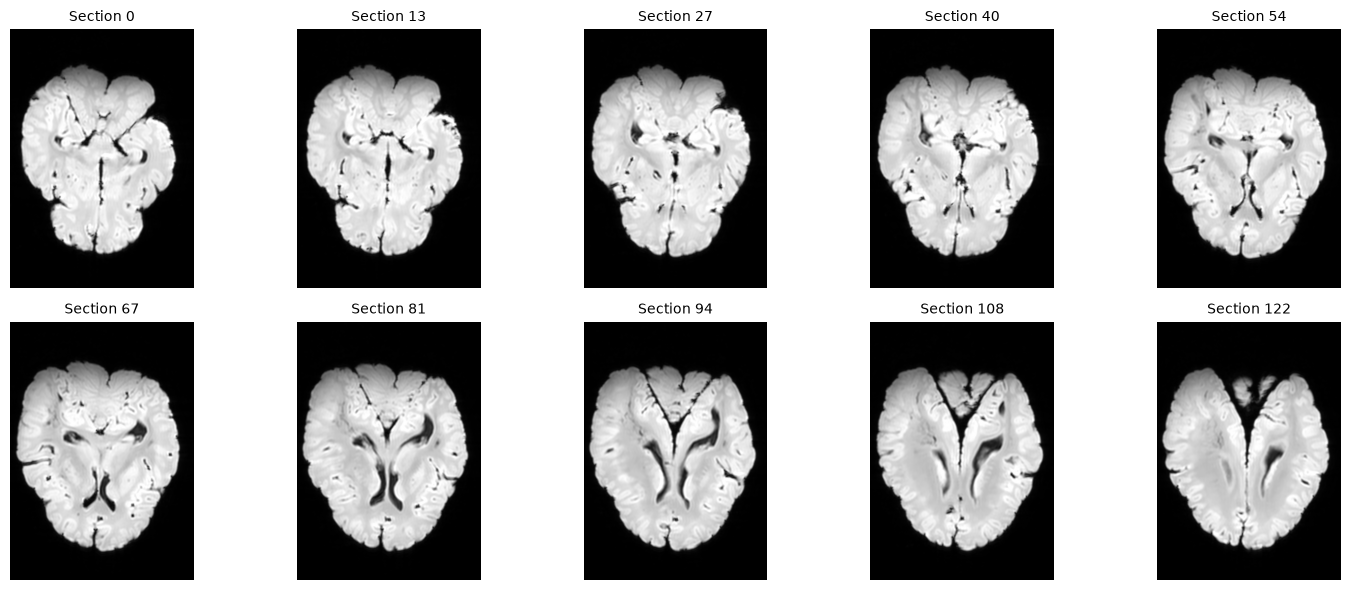

{'filename': 'MRI_SE687_X414_Y698_Z123_1200x1200_L0_axial.npy', 'center_section': 687, 'stain': None}


In [21]:
# PASTE Google Drive file ID:
ROI_DRIVE_ID="1qqn8lGOTgObky0DPabxkqmi7MOVr1c7O"
roi, meta = load_and_preview_roi(ROI_DRIVE_ID, return_meta=True)
print(meta)

# Already have a local .npy file? Use this instead:
# roi = load_roi("my_roi.npy")

## 3. Explore

In [22]:
# Shape, data type, size and intensity statistics
roi_info(roi)

shape     : (123, 1200, 854, 1)
dtype     : uint8
size_mb   : 120.21
sections  : 123
min       : 0.0
max       : 255.0
mean      : 97.72208450429352
std       : 104.85322637005443
(min/max/mean/std from 20 of 123 sections)


{'shape': (123, 1200, 854, 1),
 'dtype': 'uint8',
 'size_mb': 120.21,
 'sections': 123,
 'min': 0.0,
 'max': 255.0,
 'mean': 97.72208450429352,
 'std': 104.85322637005443}

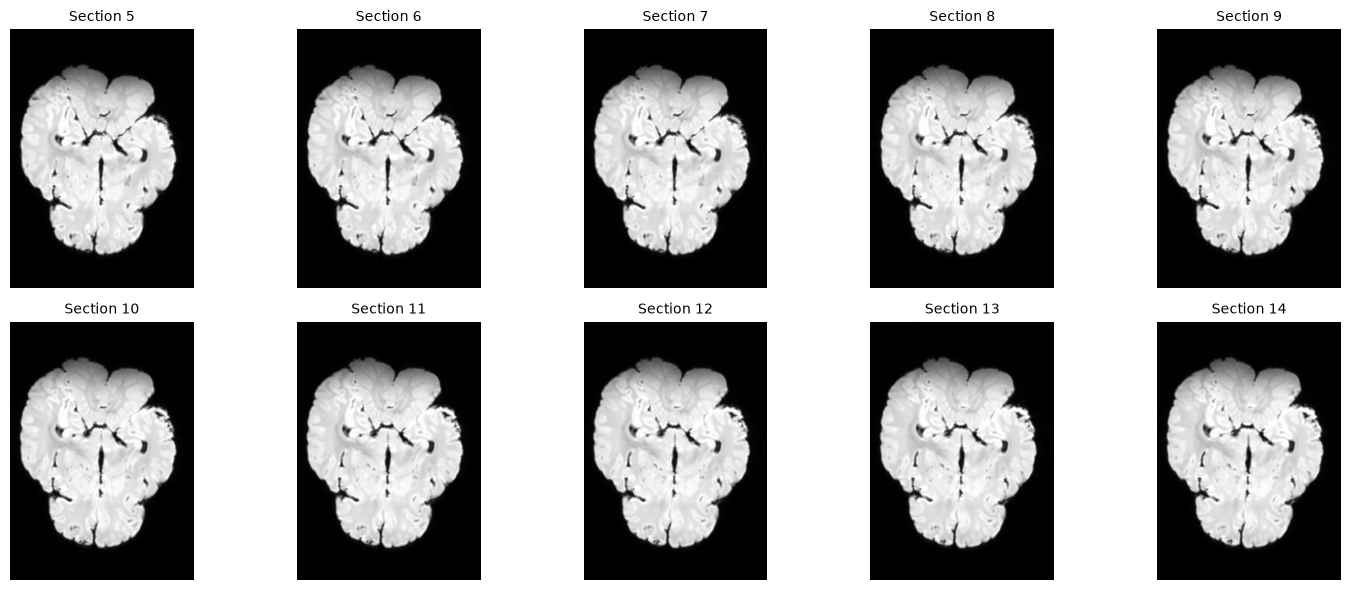

In [23]:
# Preview a range of sections (the end number is not included)
preview_sections(roi, start=5, end=15)

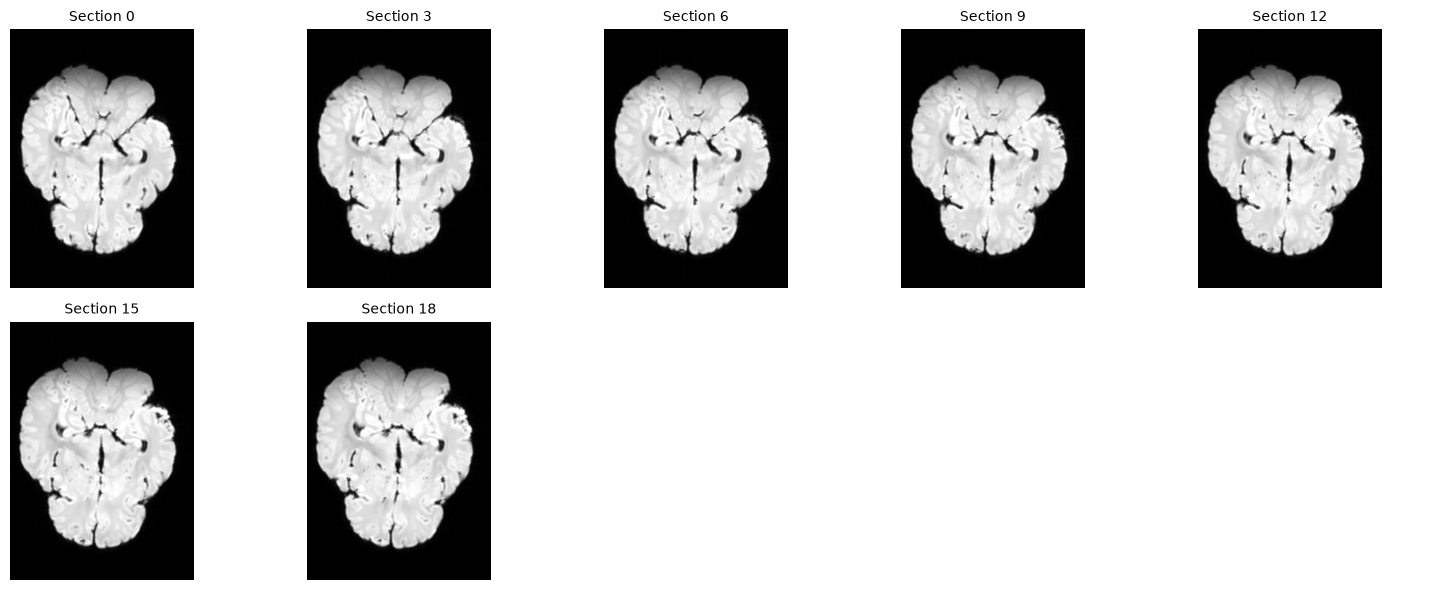

In [24]:
# Preview only some sections - every 3rd one here
preview_sections(roi, start=0, end=21, step=3)

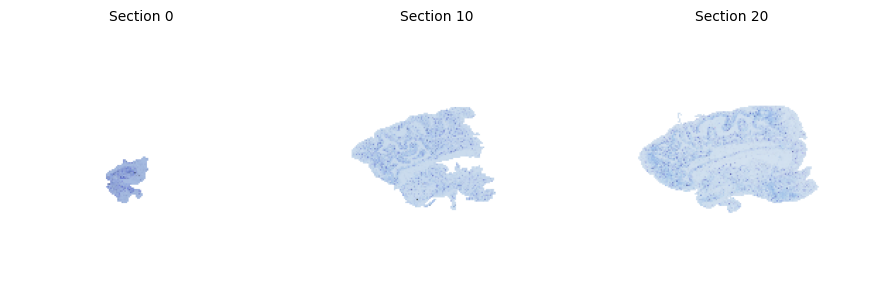

In [ ]:
# Preview exactly the sections you choose
preview_sections(roi, sections=[0, 10, 20])

## 4. Prepare for ML

In [ ]:
# Take a sub-stack of sections 5 to 14
sub = get_sections(roi, 5, 15)
print(sub.shape)

(10, 768, 768, 3)


In [ ]:
# Colour (RGB) -> one grayscale channel
gray = to_grayscale(sub)
print(gray.shape)

(10, 768, 768)


In [ ]:
# Crop the middle 256 x 256 pixels of every section
cropped = center_crop(gray, 100)
# Or pick exact rows/columns: crop_roi(gray, y=(50, 300), x=(50, 300))
print(cropped.shape)

(10, 100, 100)


In [ ]:
# Make each section 2x smaller (averages neighbouring pixels)
small = downsample_roi(cropped, factor=2)
print(small.shape)

(10, 50, 50)


In [ ]:
# Scale intensities to 0-1 (clip_percentiles ignores extreme outliers)
# Use method="zscore" for mean 0 / std 1 instead
x = normalize_roi(small, clip_percentiles=(1, 99))
print(x.dtype, x.min(), x.max())

float32 0.0 1.0


In [ ]:
# Convert to a PyTorch tensor shaped (sections, channels, height, width)
tensor = to_torch(x)
print(tensor.shape)

torch.Size([10, 1, 50, 50])


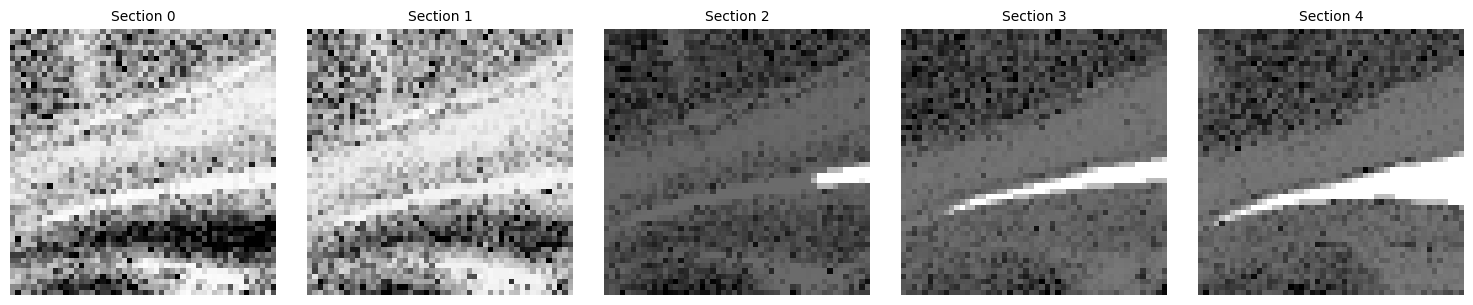

In [ ]:
# Quick look at the final result
preview_sections(x, start=0, end=5)

In [5]:

# per-section QC table (your existing roi = inspect_dataset(DATASETS['NISL_L7'], 'NISL_L7') stays as is)
import pandas as pd
st = section_stats(roi)                 # dict of per-section arrays
df = pd.DataFrame(st)
display(df.describe().T[["min","50%","max"]])


,min,50%,max
mean,93.352737,98.053675,100.998083
std,101.898410,105.166776,107.688410
p1,0.000000,0.000000,0.000000
p99,250.000000,254.000000,255.000000
dynamic_range,250.000000,254.000000,255.000000
sharpness,3.376538,3.988040,4.497036
white_frac,0.022516,0.037013,0.054481
zero_frac,0.257212,0.267762,0.309800
tissue_frac,0.690200,0.732238,0.742788
section,0.000000,61.000000,122.000000


In [6]:
anomalies = find_section_anomalies(roi)
anomaly_df = pd.DataFrame(anomalies)
display(anomaly_df)


,section,d_prev,d_next,d_skip,score


In [8]:
rows = resolve_atlas_sections(
    anomaly_df["section"].tolist(),
    biosample_id=580,
    stain="NISL",
    center_section=meta["center_section"],
    n_sections=len(roi),
)

atlas_df = pd.DataFrame(rows)
display(atlas_df)


ValueError: A stack of 123 sections can't come from a list of 116 sections.

,section,reason,value,expected_range
2,54,small_tissue,0.686418,"(0.7303068712022569, 0.8113055419921875)"


3 expected end-of-series tapers


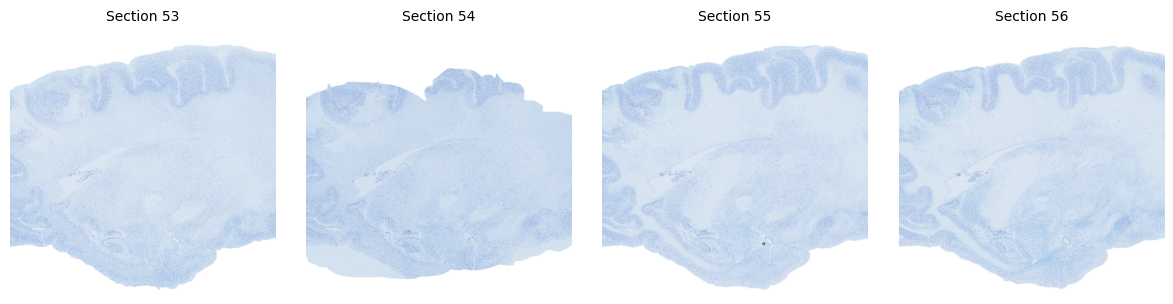

In [ ]:
# flag bad sections (replaces find_outlier_sections)
flags = flag_sections(st)
flag_df = pd.DataFrame(flags, columns=["section","reason","value","expected_range"])
display(flag_df[~flag_df.reason.str.startswith("series_end")])   # real defects
print(len(flag_df[flag_df.reason.str.startswith("series_end")]), "expected end-of-series tapers")
preview_sections(roi, sections=[53, 54, 55, 56])


largest transitions (N -> N+1): [(114, 0.62), (54, 0.35), (0, 0.33), (53, 0.32), (1, 0.31)]


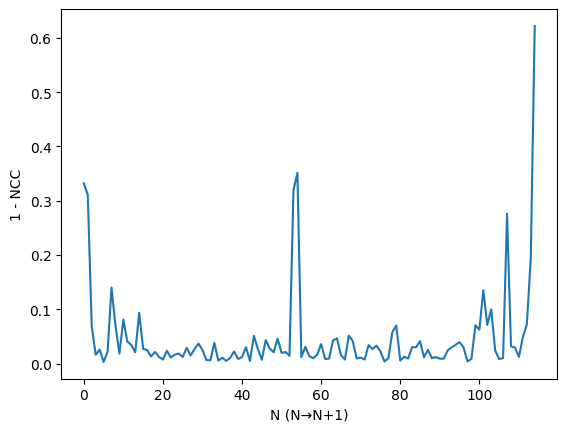

In [ ]:

# Z-continuity
import numpy as np, matplotlib.pyplot as plt
d = adjacent_change(roi)                # 1 - NCC between sections N and N+1, length Z-1
z, ref, sc = local_zscore(d, window=9)
print("largest transitions (N -> N+1):", [(int(i), round(float(d[i]), 2)) for i in np.argsort(-d)[:5]])
plt.plot(d); plt.xlabel("N (N→N+1)"); plt.ylabel("1 - NCC"); plt.show()


========== Section 5 ==========


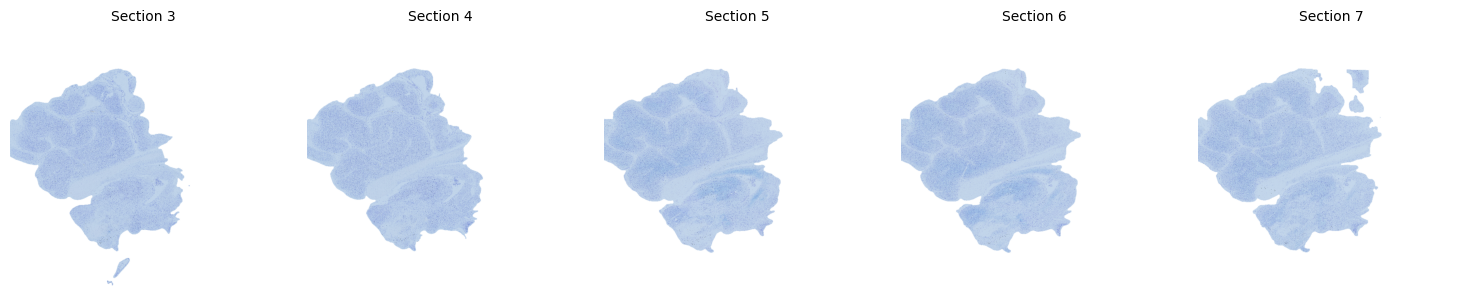


========== Section 8 ==========


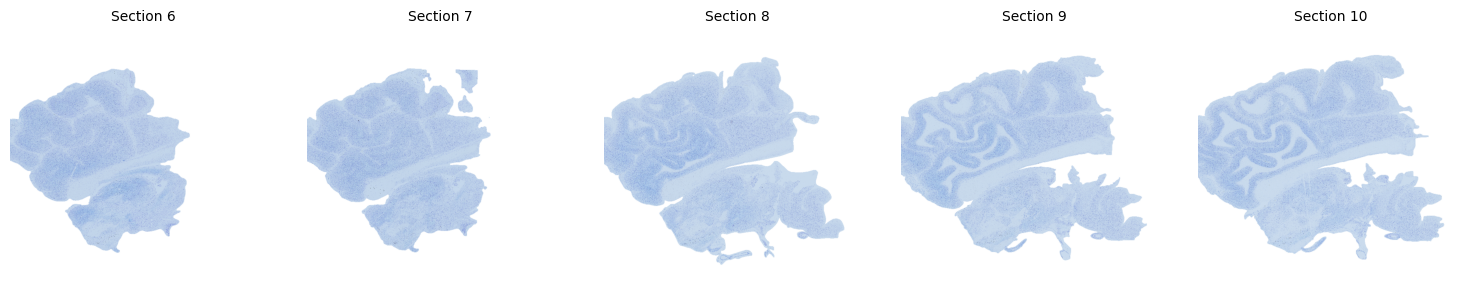


========== Section 15 ==========


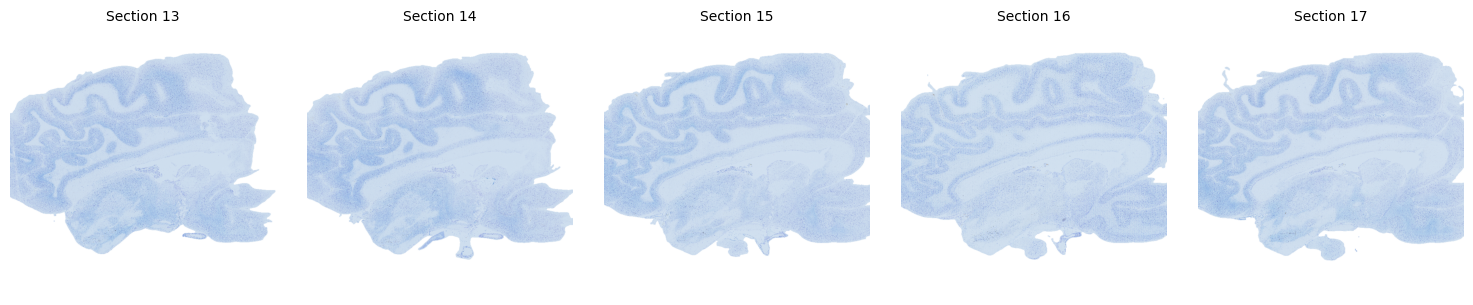


========== Section 54 ==========


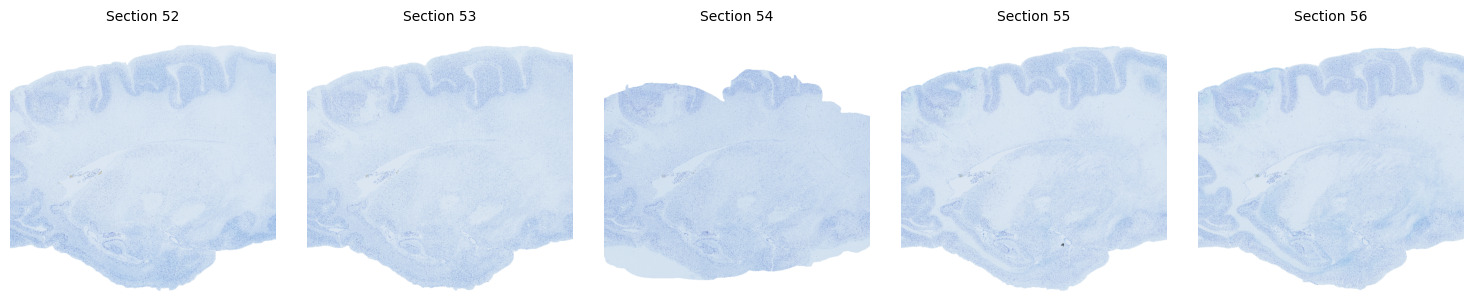


========== Section 80 ==========


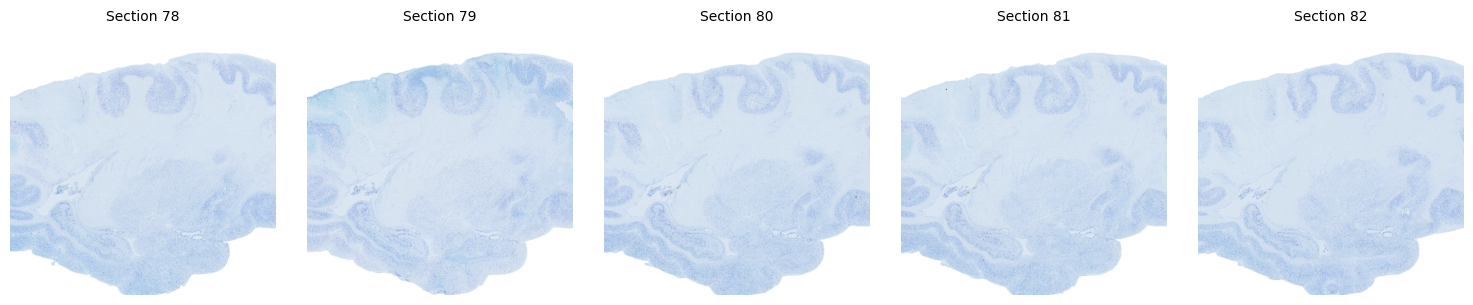


========== Section 102 ==========


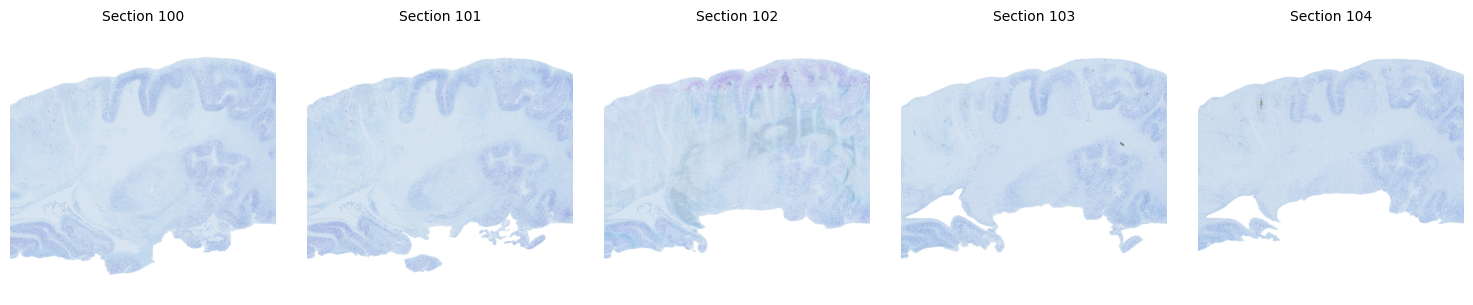


========== Section 108 ==========


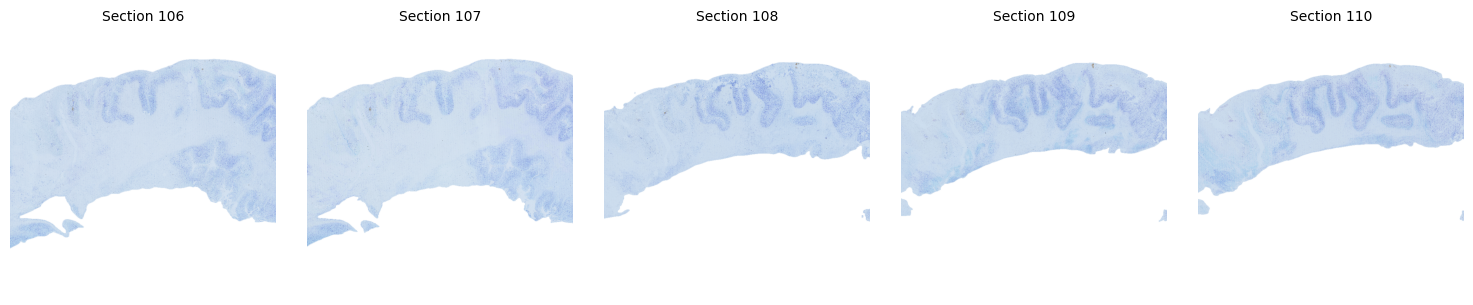

In [ ]:
for s in [5, 8, 15, 54, 80, 102, 108]:
    print(f"\n========== Section {s} ==========")
    preview_sections(
        roi,
        sections=[s-2, s-1, s, s+1, s+2]
    )

In [ ]:

# tissue mask and OD for a single section
m = tissue_mask(roi[len(roi)//2])       # bool (H, W)
od = to_od(roi[len(roi)//2])            # summed optical density, white ≈ 0
print("coverage:", m.mean())

coverage: 0.7699025472005209


### Stroke histology annotations
Overlay Stroke annotations (GFAP, CD68, ...) from the c-stroke OpenAtlas API on the ROI. Helpers live in `annotations_utils.py`, next to `roi_utils.py`. **The ROI array is only read, never modified.**

In [28]:
# !wget -q -O annotations_utils.py https://raw.githubusercontent.com/24f2007780/colab_export_roi/refs/heads/main/annotations_utils.py

import sys
from pathlib import Path
if ".." not in sys.path:
    sys.path.append("..")

import importlib
import annotations_utils
importlib.reload(annotations_utils)
from annotations_utils import *
import pandas as pd


**Which annotation types exist for a section?** Only headers are checked; a type that does not exist is simply `available=False`.

In [29]:
available = find_available_annotations(
    biosample_id=313,
    stain="IHCS",
    section_num=1193
)
display(pd.DataFrame(available))

NameError: name 'find_available_annotations' is not defined

Load only the available ones (registered OpenAtlas coordinates, not yet ROI pixels):

In [ ]:
annotations = load_stroke_annotations(
    biosample_id=313,
    stain="IHCS",
    section_num=1193
)
print(len(annotations), "polygons;", sorted({a["protein"] for a in annotations}))
print(annotation_bounds(annotations))   # implied full-resolution pixel extent: must fit inside the section

Overlay them on the corresponding ROI section. The ROI metadata (`center_X`, `center_Y`, level) decides where the ROI sits in the registered space; polygons are clipped to the ROI. The `section_index` below is the stack index of Atlas section 1193 (the stack is centred on `meta["center_section"]`).

In [ ]:
section_index = len(roi) // 2          # stack index of the centre section, SE{meta["center_section"]}
annotations_in_roi = to_roi_coordinates(annotations, roi, meta)   # new records; `annotations` is untouched
print(len(annotations_in_roi), "of", len(annotations), "polygons intersect the ROI")
preview_annotations(roi, annotations_in_roi, section_index=section_index)

#### Whole ROI stack
Stack index → Atlas section (via `resolve_atlas_sections`) → available proteins → polygons → ROI coordinates → clipped. Sections can have different annotation types.

In [ ]:
roi_annotations = load_roi_annotations(
    roi,
    meta,
    biosample_id=313
)
# roi_annotations[stack_index]            -> {protein: [records]}
# roi_annotations[stack_index]["GFAP"]    -> polygons (a KeyError means that protein does not exist for that section)
sections_with_annotations = [i for i, d in roi_annotations.items() if any(d.values())]
print(sections_with_annotations)

In [ ]:
i = sections_with_annotations[0] if sections_with_annotations else 0
preview_annotations(roi, roi_annotations, section_index=i)
preview_annotations(roi, roi_annotations, section_index=i, proteins=["GFAP", "CD68"])   # only these

overlay = create_annotation_overlay(roi, roi_annotations, section_index=i)   # separate RGB array
masks   = create_annotation_masks(roi, roi_annotations, section_index=i)     # {protein: bool mask}

In [ ]:
# The original ROI is never written to; check it yourself:
import hashlib
before = hashlib.sha256(roi.tobytes()).hexdigest()
_ = create_annotation_overlay(roi, roi_annotations, section_index=i)
assert hashlib.sha256(roi.tobytes()).hexdigest() == before
print("roi unchanged")